In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [7]:
device = "cpu"

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

print("Training samples:", len(train_dataset))

Training samples: 60000


In [10]:
class DeepNetwork(nn.Module):
    def __init__(self):
        super(DeepNetwork, self).__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.model(x)

In [11]:
def train_model(use_clipping=False, max_norm=1.0, learning_rate=1.0, epochs=5):
    model = DeepNetwork().to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    epoch_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            # Clear old gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Backward pass: gradients are computed here
            loss.backward()

            # Gradient clipping happens AFTER backward and BEFORE optimizer step
            if use_clipping:
                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=max_norm
                )

            # Update model weights
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        print(
            f"Epoch [{epoch + 1}/{epochs}], "
            f"Clipping={use_clipping}, "
            f"Loss={avg_loss:.4f}"
        )

    return epoch_losses

In [16]:
loss_without_clipping = train_model(
    use_clipping=False,
    learning_rate=0.5,
    epochs=5
)

Epoch [1/5], Clipping=False, Loss=2.2825
Epoch [2/5], Clipping=False, Loss=2.3608
Epoch [3/5], Clipping=False, Loss=2.2887
Epoch [4/5], Clipping=False, Loss=2.0564
Epoch [5/5], Clipping=False, Loss=2.0408


In [17]:
loss_with_clipping = train_model(
    use_clipping=True,
    max_norm=1.0,
    learning_rate=0.5,
    epochs=5
)

Epoch [1/5], Clipping=True, Loss=0.5979
Epoch [2/5], Clipping=True, Loss=0.2035
Epoch [3/5], Clipping=True, Loss=0.1300
Epoch [4/5], Clipping=True, Loss=0.0963
Epoch [5/5], Clipping=True, Loss=0.0742


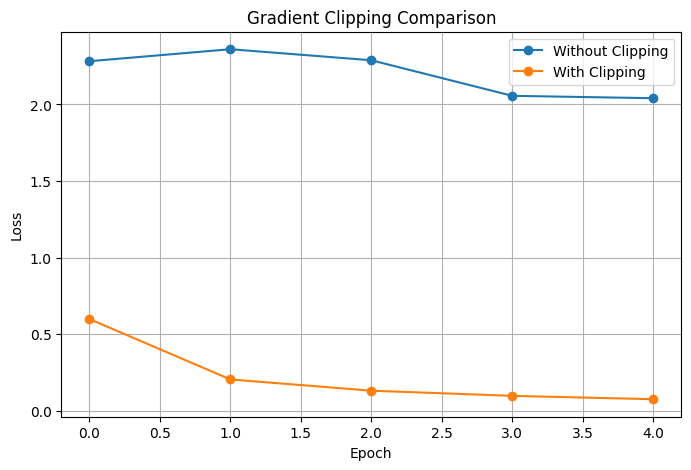

In [18]:
import numpy as np

clean_without = [
    np.nan if str(x) == 'nan' else x
    for x in loss_without_clipping
]

plt.figure(figsize=(8, 5))

plt.plot(
    clean_without,
    marker='o',
    label='Without Clipping'
)

plt.plot(
    loss_with_clipping,
    marker='o',
    label='With Clipping'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Clipping Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
|